In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../../../data/preprocessed/selected_features_dataset.csv')
X = df.drop(['price_per_m2'], axis=1)
y = df['price_per_m2']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
svr_model = joblib.load("../../../models/svr/svr_model_label_v3.joblib")


In [4]:
y_pred_train = svr_model.predict(X_train)
y_pred_test = svr_model.predict(X_test)

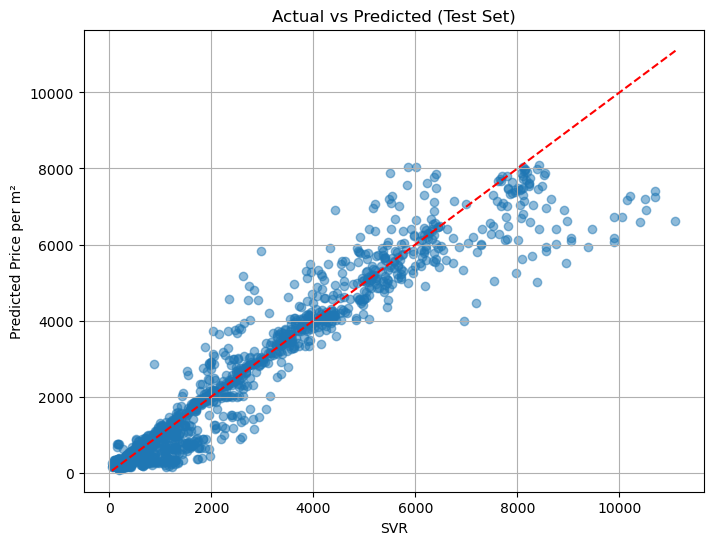

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("SVR")
plt.ylabel("Predicted Price per m²")
plt.title("Actual vs Predicted (Test Set)")
plt.grid(True)
plt.show()

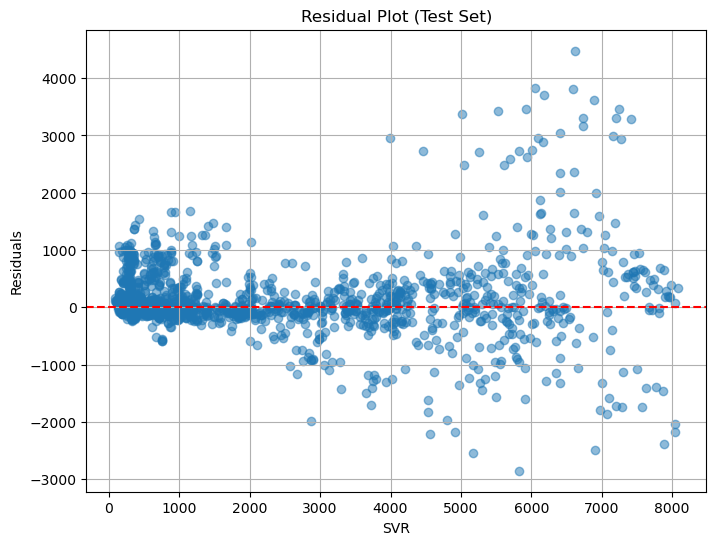

In [12]:
residuals = y_test - y_pred_test
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_test, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("SVR")
plt.ylabel("Residuals")
plt.title("Residual Plot (Test Set)")
plt.grid(True)
plt.show()

In [5]:
def calculate_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100
    return r2, mae, rmse, mape

In [6]:
train_r2, train_mae, train_rmse, train_mape = calculate_metrics(y_train, y_pred_train)
test_r2, test_mae, test_rmse, test_mape = calculate_metrics(y_test, y_pred_test)


In [7]:
print("\nCalculating cross-validated R²...")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    svr_model, 
    X_train, 
    y_train, 
    cv=kf, 
    scoring='r2',
    n_jobs=-1
)
cv_r2 = np.mean(cv_scores)


Calculating cross-validated R²...


In [8]:
metrics_data = [
    ['R2 (Test)', f"{test_r2:.4f}"],
    ['MAE', f"{test_mae:.4f}"],
    ['RMSE', f"{test_rmse:.4f}"],
    ['MAPE', f"{test_mape:.4f}%"],
    ['Train R2', f"{train_r2:.4f}"],
    ['CV R2', f"{cv_r2:.4f}"]
]

metrics_df = pd.DataFrame(metrics_data, columns=['Metric', 'Value'])
print("\nSVR Model Performance Summary:")
print("=" * 50)
print(metrics_df.to_string(index=False))
print("=" * 50)


SVR Model Performance Summary:
   Metric    Value
R2 (Test)   0.9274
      MAE 321.9241
     RMSE 613.1032
     MAPE 24.1818%
 Train R2   0.9231
    CV R2   0.9182
